# 0. Data 전처리

In [1]:
import pandas as pd
from IPython.display import display
df = pd.read_csv("https://ds-lecture-data.s3.ap-northeast-2.amazonaws.com/datasets/vgames2.csv")

df.dropna(inplace=True) # 결측치 제거
df.info() # 결측치 확인
print(df.describe())

def KMReplace(series):
  #series=series.apply(str)
  col=[]
  for data in series:
    if data[-1]=='K':
      value=float(data[:-1])*1000
    elif data[-1]=='M':
      value=float(data[:-1])*1000000
    else:
      value=float(data)*1000000
    col.append(value)
  return col


df.drop(columns=['Unnamed: 0'], inplace=True) #의미 없으니 열 제거
df['Year']=df['Year'].apply(int) #년도 정수로 표기
df.loc[(df['Year']>=0) & (df['Year']<=22),'Year']+=2000
df.loc[(df['Year']>22) & (df['Year']<100),'Year']+=1900
df.loc[:,'NA_Sales':'Other_Sales']=df.loc[:,'NA_Sales':'Other_Sales'].apply(KMReplace) #수치 통일 되어 있지 않는 Sales 항목 통일
df['Total_Sales']=df.loc[:,'NA_Sales':'Other_Sales'].sum(axis=1) #Sales 합계를 Totla_Sales 항목에 저장


df.info()
print(df.describe())
df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16241 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   16241 non-null  int64  
 1   Name         16241 non-null  object 
 2   Platform     16241 non-null  object 
 3   Year         16241 non-null  float64
 4   Genre        16241 non-null  object 
 5   Publisher    16241 non-null  object 
 6   NA_Sales     16241 non-null  object 
 7   EU_Sales     16241 non-null  object 
 8   JP_Sales     16241 non-null  object 
 9   Other_Sales  16241 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.4+ MB
         Unnamed: 0          Year
count  16241.000000  16241.000000
mean    8291.719845   1994.178437
std     4792.062774    155.484265
min        1.000000      0.000000
25%     4143.000000   2003.000000
50%     8284.000000   2007.000000
75%    12441.000000   2010.000000
max    16598.000000   2020.000000
<class 'pandas.core

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
0,Candace Kane's Candy Factory,DS,2008,Action,Destineer,40000.0,0.0,0.0,0.0,40000.0
1,The Munchables,Wii,2009,Action,Namco Bandai Games,170000.0,0.0,0.0,10000.0,180000.0
2,Otome wa Oanesama Boku ni Koi Shiteru Portable,PSP,2010,Adventure,Alchemist,0.0,0.0,20000.0,0.0,20000.0
3,Deal or No Deal: Special Edition,DS,2010,Misc,Zoo Games,40000.0,0.0,0.0,0.0,40000.0
4,Ben 10 Ultimate Alien: Cosmic Destruction,PS3,2010,Platform,D3Publisher,120000.0,90000.0,0.0,40000.0,250000.0


# 1. 지역에 따라서 선호하는 게임 장르가 다를까

In [2]:
from scipy.stats import chi2_contingency

df_sum=df.groupby('Genre').sum()
df_sum.drop(columns=['Year','Total_Sales'],axis=1,inplace=True)

# 독립변수 : 장르
# 종속변수 : 국가별 판매량
# 귀무가설 : 비율 차이가 없다. (=지역마다 선호하는 장르가 같다.)
_, p, _, _= chi2_contingency(df_sum, correction=False)
if(p<0.05) : 
    print('p value:', p,"\n"+'귀무가설을 기각한다. 지역마다 선호하는 장르가 다르다.')
else :
    print('p value:', p,"\n"+'귀무가설을 기각하지 못한다. 지역마다 선호하는 장르가 같다.')

p value: 0.0 
귀무가설을 기각한다. 지역마다 선호하는 장르가 다르다.


              NA_Sales  EU_Sales  JP_Sales  Other_Sales
Genre                                                  
Action        0.199383  0.214592  0.123172     0.234870
Adventure     0.023633  0.026596  0.040798     0.021318
Fighting      0.051160  0.041737  0.068539     0.046147
Misc          0.091648  0.086962  0.081942     0.092728
Platform      0.103407  0.083820  0.102667     0.065678
Puzzle        0.028228  0.021086  0.044235     0.015880
Racing        0.082354  0.098188  0.044298     0.097668
Role-Playing  0.074009  0.076492  0.269728     0.072418
Shooter       0.133382  0.129610  0.030030     0.130028
Simulation    0.042124  0.047206  0.049977     0.039981
Sports        0.154923  0.154986  0.105994     0.168950
Strategy      0.015749  0.018725  0.038619     0.014335


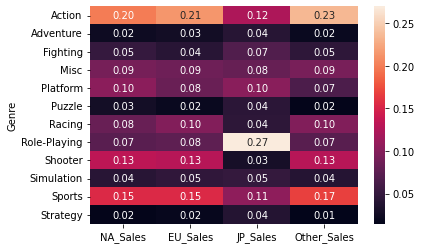

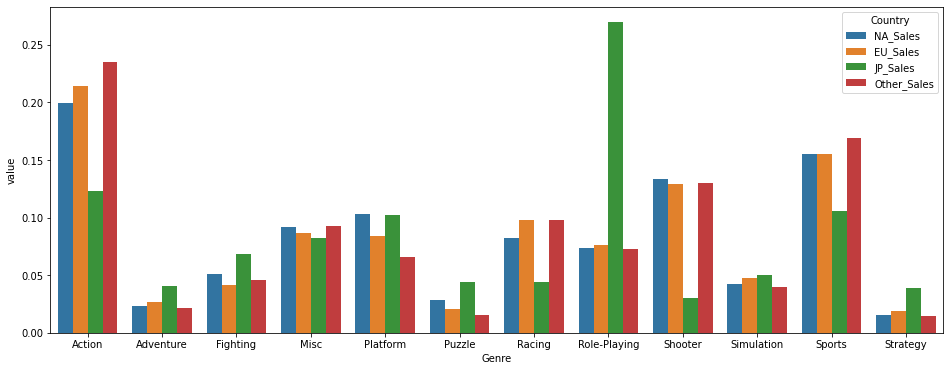

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
df_perc=df_sum.div(df_sum.sum(axis=0),axis=1)
print(df_perc)
sns.heatmap(df_perc, annot=True, fmt=".2f")
plt.show()
df_perc2=pd.melt(df_perc.reset_index(),id_vars=['Genre'])
df_perc2.rename(columns={'variable':'Country'},inplace=True)
plt.figure(figsize=(16,6))
sns.barplot(data=df_perc2,
            x="Genre",
            y="value",
            hue="Country")
plt.show()

In [4]:
#일본을 제외한 경우
df_sum_nojp=df_sum.drop(columns=['JP_Sales'],axis=1)

_, p, _, _= chi2_contingency(df_sum_nojp, correction=False)
if(p<0.05) : 
    print('p value:', p,"\n"+'귀무가설을 기각한다. 지역마다 선호하는 장르가 다르다.')
else :
    print('p value:', p,"\n"+'귀무가설을 기각하지 못한다. 지역마다 선호하는 장르가 같다.')

p value: 0.0 
귀무가설을 기각한다. 지역마다 선호하는 장르가 다르다.


# 2. 연도별 게임의 트렌드가 있을까

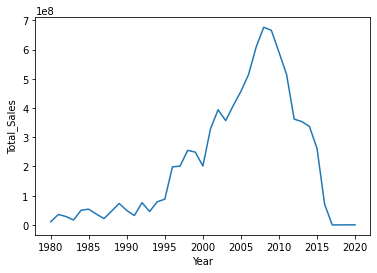

In [5]:
#연도별 게임 판매량
df_year_sum=df.groupby(['Year']).sum()

sns.lineplot(x='Year',y='Total_Sales',data=df_year_sum)

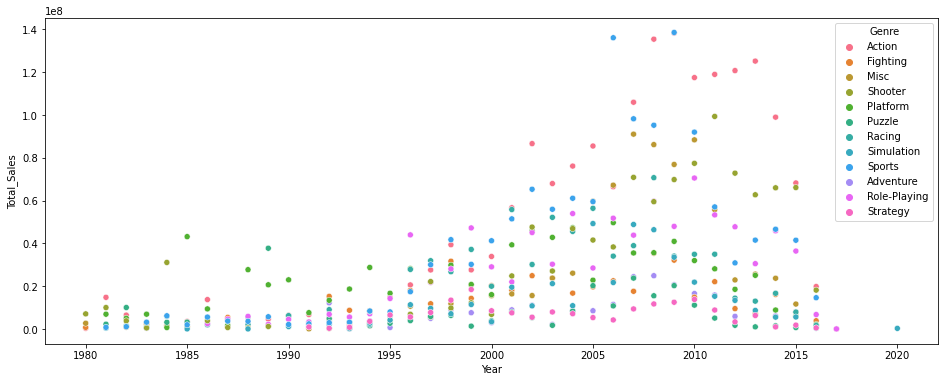

     Year         Genre    NA_Sales    EU_Sales    JP_Sales  Other_Sales  \
3    1980       Shooter   6560000.0    430000.0         0.0      80000.0   
4    1981        Action  13860000.0    810000.0         0.0     120000.0   
14   1982        Puzzle   9350000.0    580000.0         0.0     110000.0   
21   1983      Platform   2800000.0    430000.0   3620000.0      80000.0   
30   1984       Shooter  27790000.0    850000.0   1960000.0     500000.0   
34   1985      Platform  29930000.0   3770000.0   8670000.0     800000.0   
39   1986        Action   6520000.0   1660000.0   5310000.0     250000.0   
47   1987      Fighting   2800000.0    650000.0   1870000.0     100000.0   
53   1988      Platform  16340000.0   4990000.0   5700000.0     700000.0   
63   1989        Puzzle  26540000.0   3610000.0   6770000.0     830000.0   
68   1990      Platform  14140000.0   3990000.0   4280000.0     570000.0   
78   1991      Platform   4360000.0   1190000.0   1910000.0     170000.0   
88   1992   

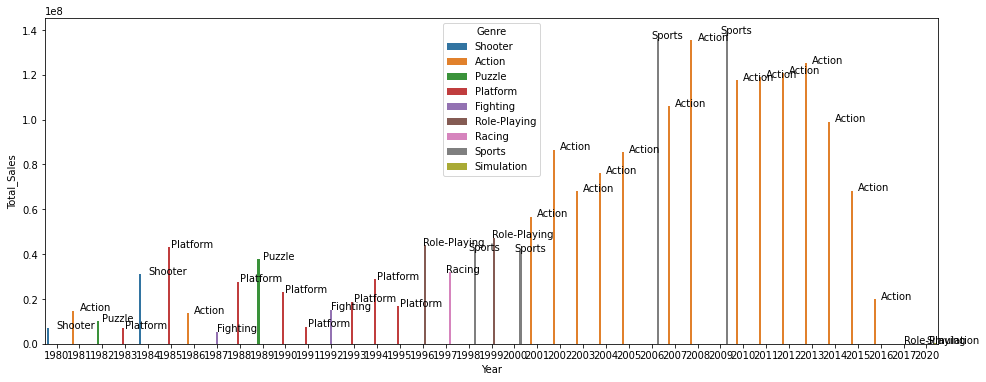

In [6]:
import numpy as np
#연도별 게임장르
df_year_genre_sum=df.groupby(['Year','Genre']).sum()
plt.figure(figsize=(16,6))
sns.scatterplot(x='Year',y='Total_Sales',hue='Genre',data=df_year_genre_sum)
plt.show()

df_year_genre_best=df.groupby(['Year','Genre']).sum().reset_index()
df_year_genre_best_value=df_year_genre_best.groupby(['Year'])['Total_Sales'].transform(max)
df_year_genre_best_index=df_year_genre_best['Total_Sales']==df_year_genre_best_value
df_year_genre_best=df_year_genre_best[df_year_genre_best_index]
print(df_year_genre_best)

plt.figure(figsize=(16,6))
plot=sns.barplot(x='Year',y='Total_Sales',hue='Genre',data=df_year_genre_best)
text = df_year_genre_best['Genre'].values
for year, value in enumerate(df_year_genre_best['Total_Sales']):
    plot.text(x=year, y=value + 5, s=str(text[year]))
plt.show()

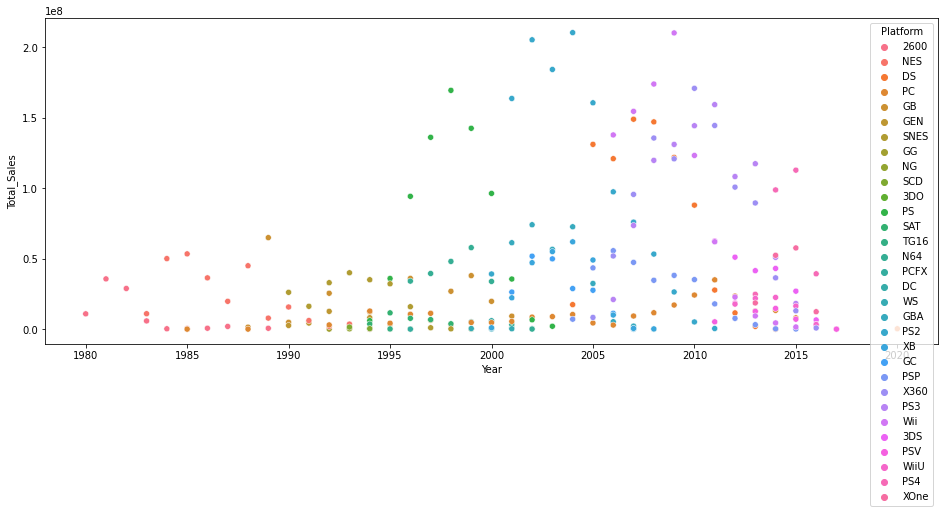

     Year Platform     NA_Sales    EU_Sales    JP_Sales  Other_Sales  \
0    1980     2600   10130000.0    640000.0         0.0     110000.0   
1    1981     2600   33400000.0   1960000.0         0.0     320000.0   
2    1982     2600   26920000.0   1650000.0         0.0     310000.0   
4    1983      NES    2320000.0    460000.0   8100000.0      80000.0   
6    1984      NES   33020000.0   2090000.0  14270000.0     700000.0   
9    1985      NES   33310000.0   4680000.0  14540000.0     910000.0   
12   1986      NES   11870000.0   2800000.0  19810000.0    1930000.0   
14   1987      NES    6620000.0   1320000.0  11630000.0     190000.0   
17   1988      NES   22360000.0   6300000.0  15410000.0     940000.0   
20   1989       GB   39810000.0   7600000.0  16160000.0    1400000.0   
25   1990     SNES   15280000.0   4600000.0   5600000.0     670000.0   
29   1991     SNES    5470000.0   1840000.0   8540000.0     370000.0   
35   1992     SNES    9520000.0   3290000.0  19670000.0     5000

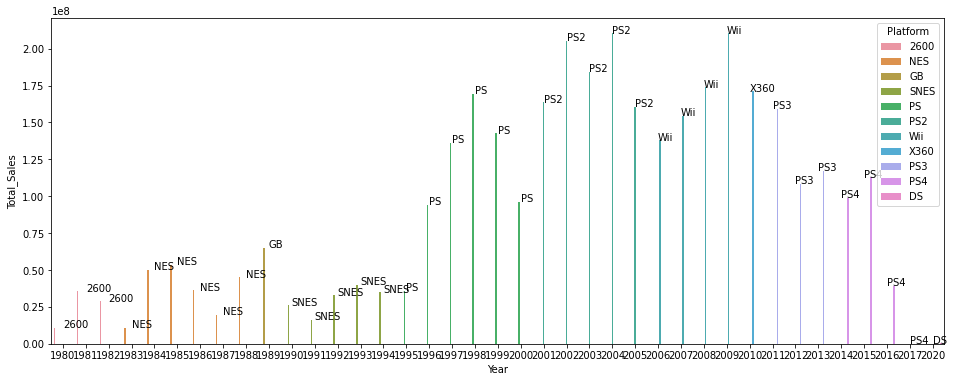

In [7]:
#연도별 플랫폼
df_year_platform_sum=df.groupby(['Year','Platform']).sum()
plt.figure(figsize=(16,6))
sns.scatterplot(x='Year',y='Total_Sales',hue='Platform',data=df_year_platform_sum)
plt.show()


df_year_platform_best=df.groupby(['Year','Platform']).sum().reset_index()
df_year_platform_best_value=df_year_platform_best.groupby(['Year'])['Total_Sales'].transform(max)
df_year_platform_best_index=df_year_platform_best['Total_Sales']==df_year_platform_best_value
df_year_platform_best=df_year_platform_best[df_year_platform_best_index]
print(df_year_platform_best)
plt.figure(figsize=(16,6))
plot=sns.barplot(x='Year',y='Total_Sales',hue='Platform',data=df_year_platform_best)
text = df_year_platform_best['Platform'].values
for year, value in enumerate(df_year_platform_best['Total_Sales']):
    plot.text(x=year, y=value + 5, s=str(text[year]))
plt.show()

# 3. 출고량이 높은 게임에 대한 분석 및 시각화 프로세스

In [8]:
df_sort=df[df['Year']>=2010].sort_values(by=['Total_Sales'], axis=0, ascending=False)
df_sort=df_sort[0:100]
print("2010년 이후 판매량 상위 100")
display(df_sort)
df_sort_sum=df_sort.groupby(['Name','Genre']).sum().sort_values(by=['Total_Sales'], axis=0, ascending=False)
print("2010년 이후 판매량 상위 100(플랫폼 통합)")
display(df_sort_sum)

2010년 이후 판매량 상위 100


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
4343,Kinect Adventures!,X360,2010,Misc,Microsoft Game Studios,14970000.0,4940000.0,240000.0,1670000.0,21820000.0
3483,Grand Theft Auto V,PS3,2013,Action,Take-Two Interactive,7010000.0,9270000.0,970000.0,4140000.0,21390000.0
10913,Grand Theft Auto V,X360,2013,Action,Take-Two Interactive,9630000.0,5310000.0,60000.0,1380000.0,16380000.0
10621,Pokemon Black/Pokemon White,DS,2010,Role-Playing,Nintendo,5570000.0,3280000.0,5650000.0,820000.0,15320000.0
2809,Call of Duty: Modern Warfare 3,X360,2011,Shooter,Activision,9030000.0,4280000.0,130000.0,1320000.0,14760000.0
...,...,...,...,...,...,...,...,...,...,...
16332,Assassin's Creed IV: Black Flag,PS3,2013,Action,Ubisoft,1330000.0,1710000.0,130000.0,730000.0,3900000.0
537,Monster Hunter 4 Ultimate,3DS,2014,Role-Playing,Nintendo,670000.0,490000.0,2620000.0,110000.0,3890000.0
1638,The Elder Scrolls V: Skyrim,PC,2011,Role-Playing,Bethesda Softworks,1150000.0,2090000.0,0.0,640000.0,3880000.0
7769,Sports Champions,PS3,2010,Sports,Sony Computer Entertainment,2120000.0,1140000.0,100000.0,510000.0,3870000.0


2010년 이후 판매량 상위 100(플랫폼 통합)


,,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
Name,Genre,,,,,,
Grand Theft Auto V,Action,8054,23100000.0,22400000.0,1390000.0,7950000.0,54840000.0
Call of Duty: Modern Warfare 3,Shooter,4022,14570000.0,10100000.0,620000.0,2940000.0,28230000.0
Call of Duty: Black Ops II,Shooter,4024,13240000.0,10180000.0,720000.0,3640000.0,27780000.0
Call of Duty: Black Ops,Shooter,4020,15650000.0,8170000.0,590000.0,2960000.0,27370000.0
Kinect Adventures!,Misc,2010,14970000.0,4940000.0,240000.0,1670000.0,21820000.0
...,...,...,...,...,...,...,...
Assassin's Creed: Unity,Action,2014,1180000.0,1960000.0,80000.0,700000.0,3920000.0
Assassin's Creed IV: Black Flag,Action,2013,1330000.0,1710000.0,130000.0,730000.0,3900000.0
Monster Hunter 4 Ultimate,Role-Playing,2014,670000.0,490000.0,2620000.0,110000.0,3890000.0


In [9]:
print("2010년 이후 판매량 상위 100(플랫폼 통합) 통계 - 장르")
display(df_sort.groupby(['Genre']).sum().sort_values(by=['Total_Sales'], axis=0, ascending=False))
print("2010년 이후 판매량 상위 100(플랫폼 통합) 통계 - 장르 별 개수")
display(df_sort_sum.reset_index()['Genre'].value_counts())


2010년 이후 판매량 상위 100(플랫폼 통합) 통계 - 장르


,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
Genre,,,,,,
Shooter,50322,111910000.0,73560000.0,5780000.0,25750000.0,217000000.0
Action,50305,68370000.0,65880000.0,5440000.0,23540000.0,163230000.0
Role-Playing,26155,35700000.0,25390000.0,20050000.0,7350000.0,88490000.0
Misc,18106,45150000.0,22860000.0,860000.0,7160000.0,76030000.0
Sports,26162,18750000.0,41100000.0,640000.0,12140000.0,72630000.0
Platform,12068,19890000.0,12730000.0,8600000.0,3130000.0,44350000.0
Racing,8046,12910000.0,12900000.0,4810000.0,3970000.0,34590000.0
Simulation,4025,2970000.0,4340000.0,6250000.0,690000.0,14250000.0
Fighting,4028,5830000.0,2410000.0,3220000.0,1000000.0,12460000.0


2010년 이후 판매량 상위 100(플랫폼 통합) 통계 - 장르 별 개수


Action          16
Shooter         16
Role-Playing    10
Sports          10
Misc             7
Platform         6
Racing           4
Simulation       2
Fighting         1
Strategy         1
Name: Genre, dtype: int64

In [17]:
print("2010년 이후 판매량 상위 100(플랫폼 통합) 통계 - 장르별 게임 및 판매량")
display(df_sort.groupby(['Name','Genre']).sum().sort_values(by=['Genre'], axis=0).reset_index())

2010년 이후 판매량 상위 100(플랫폼 통합) 통계 - 장르별 게임 및 판매량


,Name,Genre,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
0,God of War III,Action,2010,2740000.0,1360000.0,120000.0,630000.0,4850000.0
1,Uncharted: The Nathan Drake Collection,Action,2015,1960000.0,1690000.0,80000.0,740000.0,4470000.0
2,The Last of Us,Action,4027,4190000.0,4150000.0,350000.0,1830000.0,10520000.0
3,Luigi's Mansion: Dark Moon,Action,2013,1780000.0,1390000.0,1100000.0,300000.0,4570000.0
4,The Legend of Zelda: Skyward Sword,Action,2011,2140000.0,1200000.0,370000.0,400000.0,4110000.0
...,...,...,...,...,...,...,...,...
68,FIFA 15,Sports,4028,1360000.0,7430000.0,90000.0,2540000.0,11420000.0
69,FIFA 14,Sports,4026,1700000.0,7250000.0,80000.0,2190000.0,11220000.0
70,FIFA 12,Sports,4022,1680000.0,7110000.0,130000.0,1950000.0,10870000.0
71,Zumba Fitness,Sports,2010,3500000.0,2640000.0,0.0,670000.0,6810000.0


Shooter의 판매량이 더 높지만 특정 시리즈에 쏠려있는 편이며 Action 장르가 신규 진입이 쉬워보임
뿐만 아니라 Action 장릐 판매량은 미국과 유럽이 비슷하고 미국,유럽과 일본, 다른 국가들간의 격차가 커서 시장 공략을 한다면 미국과 유럽 위주로 해야할 것

In [11]:
display(df_sort.groupby(['Name','Genre']).sum().sort_values(by=['Genre'], axis=0))

,,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
Name,Genre,,,,,,
God of War III,Action,2010,2740000.0,1360000.0,120000.0,630000.0,4850000.0
Uncharted: The Nathan Drake Collection,Action,2015,1960000.0,1690000.0,80000.0,740000.0,4470000.0
The Last of Us,Action,4027,4190000.0,4150000.0,350000.0,1830000.0,10520000.0
Luigi's Mansion: Dark Moon,Action,2013,1780000.0,1390000.0,1100000.0,300000.0,4570000.0
The Legend of Zelda: Skyward Sword,Action,2011,2140000.0,1200000.0,370000.0,400000.0,4110000.0
...,...,...,...,...,...,...,...
FIFA 15,Sports,4028,1360000.0,7430000.0,90000.0,2540000.0,11420000.0
FIFA 14,Sports,4026,1700000.0,7250000.0,80000.0,2190000.0,11220000.0
FIFA 12,Sports,4022,1680000.0,7110000.0,130000.0,1950000.0,10870000.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [12]:
print("2010년 이후 판매량 상위 100 중 Action 장르 통계")

df_sort_sum_action=df_sort.copy()
df_sort_sum_action=df_sort_sum_action[df_sort_sum_action['Genre']=='Action']
display(df_sort_sum_action)


2010년 이후 판매량 상위 100 중 Action 장르 통계


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
3483,Grand Theft Auto V,PS3,2013,Action,Take-Two Interactive,7010000.0,9270000.0,970000.0,4140000.0,21390000.0
10913,Grand Theft Auto V,X360,2013,Action,Take-Two Interactive,9630000.0,5310000.0,60000.0,1380000.0,16380000.0
2008,Grand Theft Auto V,PS4,2014,Action,Take-Two Interactive,3800000.0,5810000.0,360000.0,2020000.0,11990000.0
9035,FIFA Soccer 13,PS3,2012,Action,Electronic Arts,1060000.0,5050000.0,130000.0,2010000.0,8250000.0
11868,Uncharted 3: Drake's Deception,PS3,2011,Action,Sony Computer Entertainment,2770000.0,2800000.0,190000.0,1060000.0,6820000.0
16276,Red Dead Redemption,PS3,2010,Action,Take-Two Interactive,2790000.0,2610000.0,170000.0,1030000.0,6600000.0
1629,Assassin's Creed III,PS3,2012,Action,Ubisoft,2640000.0,2560000.0,160000.0,1140000.0,6500000.0
10131,Red Dead Redemption,X360,2010,Action,Take-Two Interactive,3700000.0,1970000.0,90000.0,570000.0,6330000.0
8082,The Last of Us,PS3,2013,Action,Sony Computer Entertainment Europe,2410000.0,2280000.0,280000.0,1010000.0,5980000.0
14823,Batman: Arkham City,PS3,2011,Action,Warner Bros. Interactive Entertainment,2700000.0,1910000.0,110000.0,800000.0,5520000.0


2010년 이후 판매량 상위 100 통계 - 플랫폼 현황


,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Total_Sales
Platform,,,,,,
X360,48272,120950000.0,61800000.0,1460000.0,17230000.0,201440000.0
PS3,48280,64240000.0,82620000.0,6340000.0,32460000.0,185660000.0
PS4,34248,35040000.0,51600000.0,2410000.0,18120000.0,107170000.0
3DS,20125,28210000.0,22180000.0,23360000.0,4780000.0,78530000.0
Wii,16084,31250000.0,17700000.0,2400000.0,4980000.0,56330000.0
WiiU,12080,14250000.0,7800000.0,5960000.0,2430000.0,30440000.0
XOne,10073,15480000.0,8090000.0,60000.0,2220000.0,25850000.0
DS,4022,8480000.0,5140000.0,8790000.0,1250000.0,23660000.0
PC,6033,6140000.0,5920000.0,0.0,1850000.0,13910000.0


2010년 이후 연도별 플랫폼 수


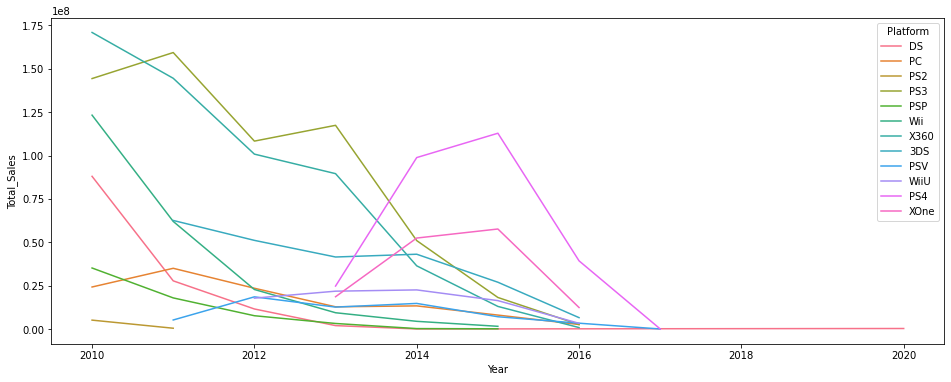

2010년 이후 Action 장르 연도별 플랫폼 수


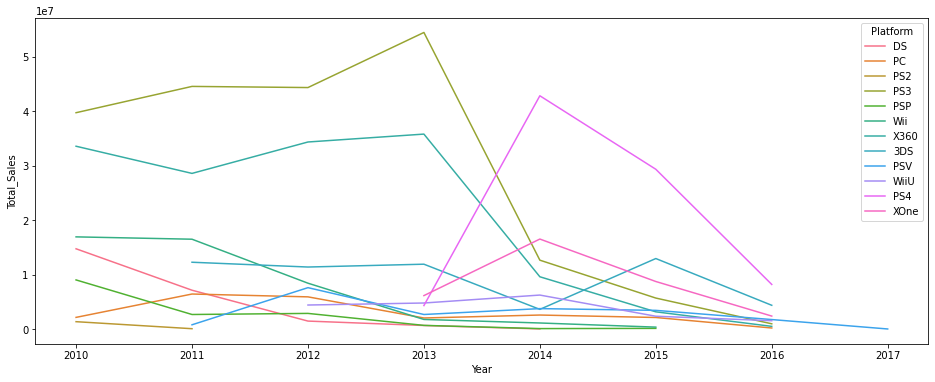

'\nprint("2010년 이후 판매량 상위 100 중 Action 장르 연도별 플랫폼 수")\ndisplay(df_sort_sum_action.groupby([\'Year\',\'Platform\']).sum())\nplt.figure(figsize=(16,6))\nsns.lineplot(x=\'Year\',y=\'Total_Sales\',hue=\'Platform\',data=df_sort_sum_action.groupby([\'Year\',\'Platform\']).sum())\nplt.show()\n'

In [19]:

print("2010년 이후 판매량 상위 100 통계 - 플랫폼 현황")
display(df_sort.groupby(['Platform']).sum().sort_values(by=['Total_Sales'], axis=0, ascending=False))


print("2010년 이후 연도별 플랫폼 수")
plt.figure(figsize=(16,6))
sns.lineplot(x='Year',y='Total_Sales',hue='Platform',data=df_year_platform_sum.reset_index()[(df_year_platform_sum.reset_index()['Year']>=2010)])
plt.show()


print("2010년 이후 Action 장르 연도별 플랫폼 수")
df_year_genre_platform_sum=df.groupby(['Year','Genre','Platform']).sum().reset_index()
plt.figure(figsize=(16,6))
sns.lineplot(x='Year',y='Total_Sales',hue='Platform',data=df_year_genre_platform_sum[(df_year_genre_platform_sum['Year']>=2010)&(df_year_genre_platform_sum['Genre']=='Action')])
plt.show()
"""
print("2010년 이후 판매량 상위 100 중 Action 장르 연도별 플랫폼 수")
display(df_sort_sum_action.groupby(['Year','Platform']).sum())
plt.figure(figsize=(16,6))
sns.lineplot(x='Year',y='Total_Sales',hue='Platform',data=df_sort_sum_action.groupby(['Year','Platform']).sum())
plt.show()
"""


결론 : 북미와 유럽을 타겟으로 한 Action 장르의 게임을 PS4환경으로 출시하자